In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [56]:
df = pd.read_csv('customer churn.csv')

In [57]:
df.head()

,Customer_ID,Gender,Region,Subscription_Plan,Payment_Method,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn
0,10001,Male,East,Basic,PayPal,27.0,27,1,61.08,0
1,10002,Unknown,West,Pro,PayPal,55.0,146,2,73.09,0
2,10003,Female,West,Pro,E-Wallet,NaN,147,2,116.30,1
3,10004,Female,south,Basic,Credit Card,NaN,34,1,0.58,1
4,10005,Male,North,Basic,Crypto,30.0,146,3,46.35,1


In [58]:
df.shape

(10300, 10)

In [59]:
df.size

103000

In [60]:
df.isna().sum()

Customer_ID                  0
Gender                       0
Region                       0
Subscription_Plan            0
Payment_Method             725
Age                       1033
Days_Since_Last_Login        0
Customer_Service_Calls       0
Monthly_Spend              514
Churn                        0
dtype: int64

In [61]:
df.fillna(df.mean(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_1684\1190112902.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [62]:
print(df.isna().sum().sum())

0


In [63]:
df.nunique().sort_values(ascending=False)

Customer_ID               10000
Monthly_Spend              6769
Days_Since_Last_Login       180
Age                          74
Customer_Service_Calls       11
Region                        8
Subscription_Plan             6
Gender                        4
Payment_Method                4
Churn                         2
dtype: int64

In [64]:
df['Customer_ID'].value_counts()

Customer_ID
10001    2
10208    2
10206    2
10205    2
10204    2
        ..
13533    1
13534    1
13535    1
13536    1
20000    1
Name: count, Length: 10000, dtype: int64

In [65]:
df['Customer_ID'].nunique()

10000

In [66]:
df['Customer_ID'].nunique() == len(df)

False

In [67]:
df.drop(columns=['Customer_ID'], axis=1, inplace=True)

In [68]:
df['Gender'].value_counts()

Gender
Male          4187
Female        4088
Non-Binary    1035
Unknown        990
Name: count, dtype: int64

In [69]:
df['Gender'].nunique()

4

In [70]:
df['Region'].value_counts()

Region
South    2350
East     2334
West     2330
North    2285
south     257
west      257
east      252
north     235
Name: count, dtype: int64

In [71]:
df['Region'] = df['Region'].str.title()

In [72]:
df['Region'].value_counts()

Region
South    2607
West     2587
East     2586
North    2520
Name: count, dtype: int64

In [73]:
df['Subscription_Plan'].value_counts()

Subscription_Plan
Basic    4517
Pro      2886
Plus     1862
BASIC     486
PRO       330
PLUS      219
Name: count, dtype: int64

In [74]:
df['Subscription_Plan'] = df['Subscription_Plan'].str.title()

In [75]:
df['Subscription_Plan'].value_counts()

Subscription_Plan
Basic    5003
Pro      3216
Plus     2081
Name: count, dtype: int64

In [76]:
df['Payment_Method'].value_counts()

Payment_Method
Crypto         3157
PayPal         2392
Credit Card    2380
E-Wallet       2371
Name: count, dtype: int64

In [77]:
df['Payment_Method'].nunique()

4

In [78]:
df = pd.get_dummies(df, columns=['Gender', 'Region', 'Subscription_Plan', 'Payment_Method'], drop_first=True, dtype='int64')

In [79]:
df['Age'] = df['Age'].astype('int64')

In [80]:
df['Age'].sample(5)

3044    33
3678    42
1228    31
456     33
1974    30
Name: Age, dtype: int64

In [81]:
df.head()

,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn,Gender_Male,Gender_Non-Binary,Gender_Unknown,Region_North,Region_South,Region_West,Subscription_Plan_Plus,Subscription_Plan_Pro,Payment_Method_Crypto,Payment_Method_E-Wallet,Payment_Method_PayPal
0,27,27,1,61.08,0,1,0,0,0,0,0,0,0,0,0,1
1,55,146,2,73.09,0,0,0,1,0,0,1,0,1,0,0,1
2,33,147,2,116.30,1,0,0,0,0,0,1,0,1,0,1,0
3,33,34,1,0.58,1,0,0,0,0,1,0,0,0,0,0,0
4,30,146,3,46.35,1,1,0,0,1,0,0,0,0,1,0,0


In [83]:
correlation = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(correlation)

Churn                      1.000000
Days_Since_Last_Login      0.262064
Customer_Service_Calls     0.164860
Region_South               0.045287
Payment_Method_PayPal      0.016308
Gender_Non-Binary          0.008562
Region_West                0.007153
Payment_Method_Crypto      0.006549
Region_North               0.004594
Monthly_Spend              0.004379
Gender_Male                0.004337
Age                       -0.000610
Payment_Method_E-Wallet   -0.000972
Gender_Unknown            -0.006512
Subscription_Plan_Pro     -0.013145
Subscription_Plan_Plus    -0.109478
Name: Churn, dtype: float64


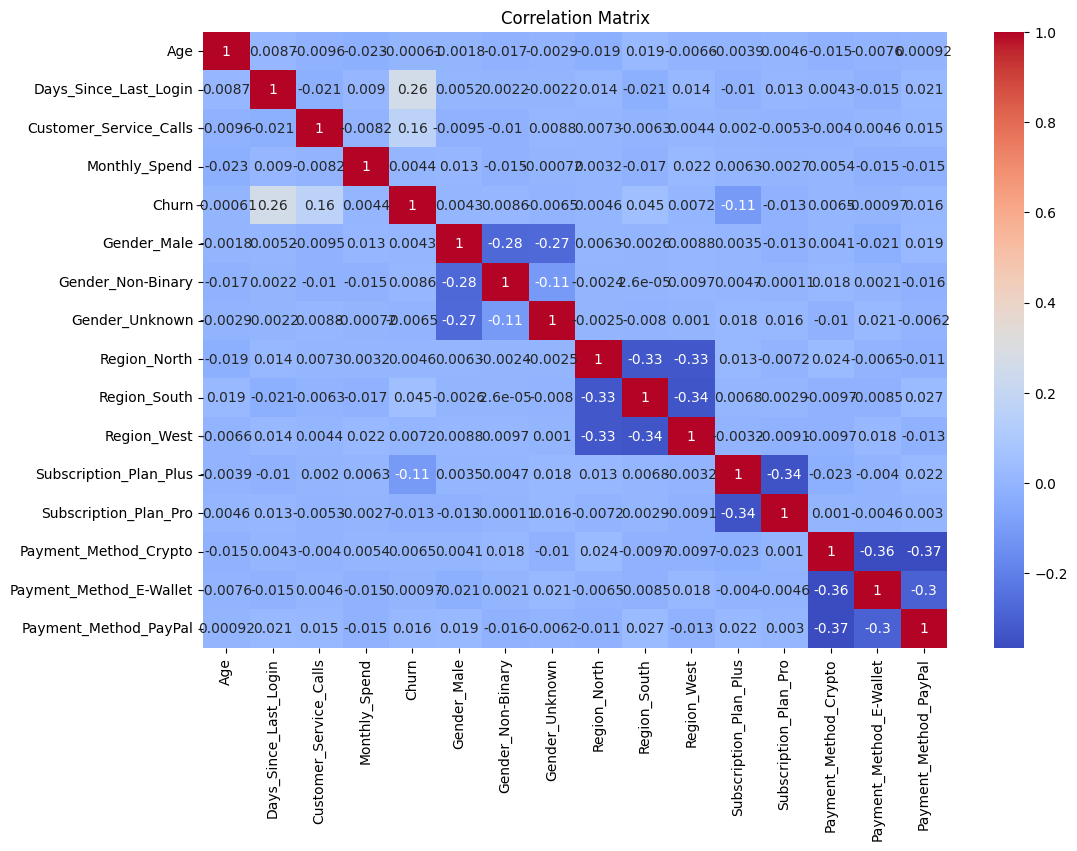

In [84]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

<Axes: xlabel='Region_North', ylabel='Churn'>

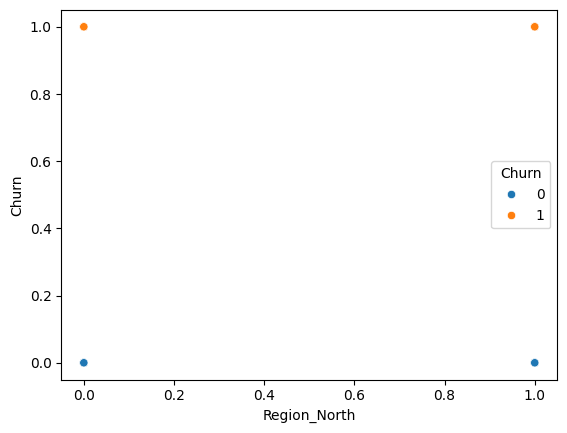

In [87]:
sns.scatterplot(x=df['Region_North'],y=df['Churn'], hue=df['Churn'])

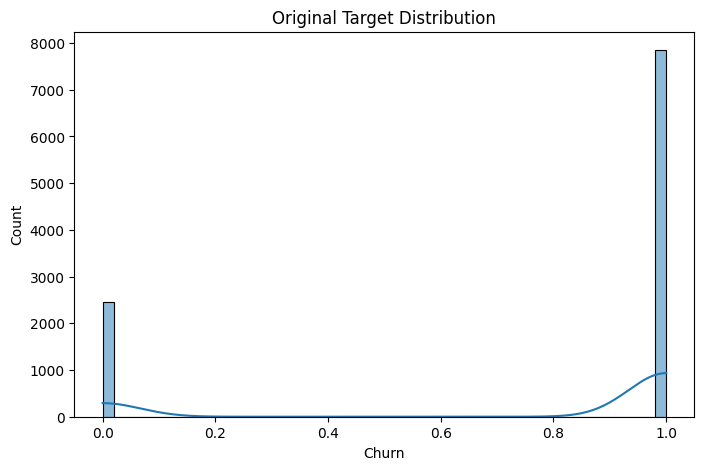

In [88]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Churn'], bins=50, kde=True)
plt.title("Original Target Distribution")
plt.show()

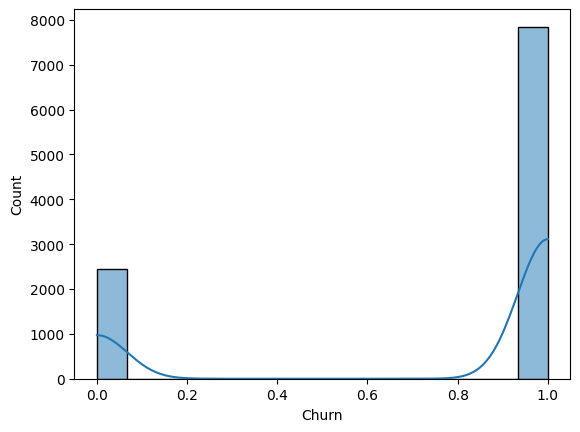

In [89]:
sns.histplot(df["Churn"], kde=True)
plt.show()

<Axes: ylabel='Churn'>

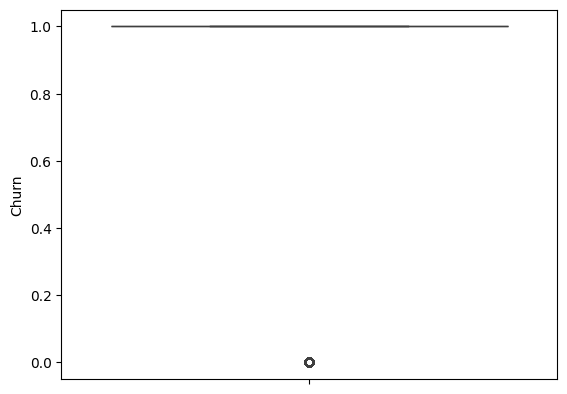

In [91]:
sns.boxplot(df['Churn'])

In [92]:
X = df.drop(columns=['Churn'], axis=1)
y = df['Churn']

In [93]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [94]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [95]:
print(X_train.shape,
      X_test.shape,
      y_train.shape,
      y_test.shape)

(8240, 15) (2060, 15) (8240,) (2060,)


In [96]:
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [97]:
np.mean(X_train_scaled, axis=0)
np.std(X_train_scaled, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [98]:
np.mean(X_test_scaled, axis=0)
np.std(X_test_scaled, axis=0)

array([1.01704669, 0.99033643, 0.98664102, 1.51002143, 0.99676555,
       0.93719013, 1.01964789, 1.00083774, 0.97779015, 1.00208289,
       0.9861957 , 1.0197826 , 1.00416636, 1.02248575, 0.97733759])

In [32]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

In [33]:
model.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score

In [36]:
accuracy_score(y_test,pred)

0.7747572815533981

In [37]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.59      0.22      0.32       496
           1       0.79      0.95      0.86      1564

    accuracy                           0.77      2060
   macro avg       0.69      0.59      0.59      2060
weighted avg       0.74      0.77      0.73      2060



In [38]:
f1_score(y_test,pred)

0.8649592549476135

In [39]:
from sklearn.metrics import balanced_accuracy_score

In [40]:
balanced_accuracy_score(y_test,pred)

0.5859510353931193

In [41]:
model.feature_importances_

array([0.18199573, 0.29118266, 0.09978091, 0.21675132, 0.02546047,
       0.01433441, 0.01474709, 0.01974537, 0.01730929, 0.02017873,
       0.01595793, 0.02150059, 0.02247615, 0.01955389, 0.01902545])

In [42]:
features = pd.DataFrame(data=model.feature_importances_, index=X.columns)

In [43]:
features

,0
Age,0.181996
Days_Since_Last_Login,0.291183
Customer_Service_Calls,0.099781
Monthly_Spend,0.216751
Gender_Male,0.025460
Gender_Non-Binary,0.014334
Gender_Unknown,0.014747
Region_North,0.019745
Region_South,0.017309
Region_West,0.020179


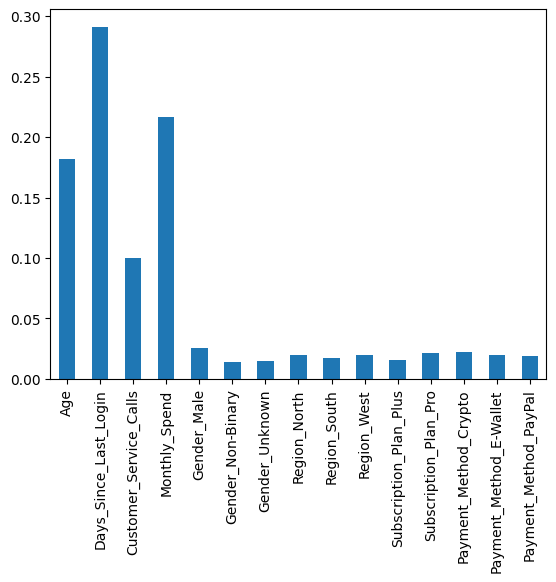

In [44]:
features.plot(kind='bar', legend=False)
plt.show()

In [45]:
X = df[['Age', 'Days_Since_Last_Login', 'Customer_Service_Calls', 'Monthly_Spend', 'Gender_Non-Binary', 'Region_South', 'Subscription_Plan_Plus', 'Payment_Method_PayPal']]
y = df['Churn']

In [46]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

In [48]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
pred1 = model.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy_score(y_test,pred1)

0.6941747572815534

In [51]:
print(classification_report(y_test,pred1))

              precision    recall  f1-score   support

           0       0.41      0.61      0.49       496
           1       0.85      0.72      0.78      1564

    accuracy                           0.69      2060
   macro avg       0.63      0.67      0.64      2060
weighted avg       0.75      0.69      0.71      2060



In [52]:
confusion_matrix(y_test,pred1)

array([[ 302,  194],
       [ 436, 1128]], dtype=int64)

In [53]:
import joblib

joblib.dump(model, "customer_churn_model.pkl", compress=9)

['customer_churn_model.pkl']

In [54]:
import os

size_mb = os.path.getsize("customer_churn_model.pkl") / (1024 * 1024)
print(size_mb)

1.486166000366211
